## 1

In [37]:
import pandas as pd

print("--- LOADING PROCESSED DATA ---")

load_path = "./processed_data/processed_videos"
videos = pd.read_csv(load_path)
videos['source'] = videos['source'].astype('Int64')

print(f"{len(videos)} videos loaded!")
pd.set_option('display.max_colwidth', None)
display(videos.sample(15))

--- LOADING PROCESSED DATA ---
7000 videos loaded!


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution
1552,559_543.mp4,1,Deepfakes,classic_559,543,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/559_543.mp4,334,25.0,13.360000,720x720
1173,176_190.mp4,1,Deepfakes,classic_176,190,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/176_190.mp4,376,30.0,12.533333,1080x1080
1862,167_166.mp4,1,Deepfakes,classic_167,166,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/167_166.mp4,341,25.0,13.640000,480x480
4758,341_340.mp4,1,FaceSwap,classic_341,340,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/341_340.mp4,293,30.0,9.766667,720x720
2051,948.mp4,0,original,classic_948,<NA>,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/948.mp4,434,30.0,14.466667,1080x1080
3660,220_219.mp4,1,FaceShifter,classic_220,219,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/220_219.mp4,357,25.0,14.280000,480x480
5129,786_819.mp4,1,NeuralTextures,classic_786,819,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/786_819.mp4,520,25.0,20.800000,1080x1080
3069,017_803.mp4,1,FaceShifter,classic_017,803,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/017_803.mp4,398,30.0,13.266667,720x720
6552,559_543.mp4,1,Face2Face,classic_559,543,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/559_543.mp4,718,25.0,28.720000,720x720
2820,996.mp4,0,original,classic_996,<NA>,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/996.mp4,312,25.0,12.480000,480x480


In [38]:
from sklearn.model_selection import train_test_split

print("--- TARGET BASED SPLIT ---")

dfd_targest = videos[videos['method'] == "DeepFakeDetection"]['target'].dropna().unique()
classic_targets = videos[videos['method'] != "DeepFakeDetection"]['target'].dropna().unique()

def split(targets_array):
    train_t, temp_t = train_test_split(targets_array, test_size=0.30, random_state=42)
    val_t, test_t = train_test_split(temp_t, test_size=0.50, random_state=42)
    return set(train_t), set(val_t), set(test_t)

train_dfd, val_dfd, test_dfd = split(dfd_targest)
train_class, val_class, test_class = split(classic_targets)

train_set = train_dfd.union(train_class)
val_set = val_dfd.union(val_class)
test_set = test_dfd.union(test_class)


def assign_split(target_id):
    if target_id in train_set:
        return 'train'
    elif target_id in val_set:
        return 'val'
    elif target_id in test_set:
        return 'test'
    else:
        'unknown'

videos['split'] = videos['target'].apply(assign_split)

display(videos.sample(10))

--- TARGET BASED SPLIT ---


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution,split
2740,489.mp4,0,original,classic_489,<NA>,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/489.mp4,566,30.0,18.866667,720x720,train
5076,158_379.mp4,1,NeuralTextures,classic_158,379,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/158_379.mp4,341,30.0,11.366667,480x480,val
4058,441_439.mp4,1,FaceSwap,classic_441,439,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/441_439.mp4,305,30.0,10.166667,480x480,train
1337,263_284.mp4,1,Deepfakes,classic_263,284,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/263_284.mp4,300,30.0,10.000000,720x720,train
5988,423_421.mp4,1,NeuralTextures,classic_423,421,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/423_421.mp4,1038,25.0,41.520000,480x480,train
5552,559_543.mp4,1,NeuralTextures,classic_559,543,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/559_543.mp4,334,25.0,13.360000,720x720,train
3824,031_163.mp4,1,FaceShifter,classic_031,163,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/031_163.mp4,482,30.0,16.066667,720x720,val
4727,361_448.mp4,1,FaceSwap,classic_361,448,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/361_448.mp4,455,30.0,15.166667,720x720,train
5789,124_085.mp4,1,NeuralTextures,classic_124,85,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/124_085.mp4,318,25.0,12.720000,480x480,val
5136,261_254.mp4,1,NeuralTextures,classic_261,254,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/261_254.mp4,427,25.0,17.080000,480x480,test


In [39]:
print("--- DATASET DISTRIBUTION ---")
print(videos['split'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- DATA LEAKAGE CHECK ---")
leakage = train_set.intersection(test_set)
print(f"Targets shared between Train and Test: {len(leakage)}")

print("\n--- CONSTRAINT CHECK ---")

print("Balance of Real (0) vs Fake (1) within the splits:")
balance_labels = pd.crosstab(videos['split'], videos['label'], normalize='index') * 100
display(balance_labels.round(1).astype(str) + '%')

print("Balance of Alteration Techniques within the splits:")
balance_methods = pd.crosstab(videos['split'], videos['method'], normalize='index') * 100
display(balance_methods.round(1).astype(str) + '%')

--- DATASET DISTRIBUTION ---
split
train    68.86%
test     15.67%
val      15.47%
Name: proportion, dtype: object

--- DATA LEAKAGE CHECK ---
Targets shared between Train and Test: 0

--- CONSTRAINT CHECK ---
Balance of Real (0) vs Fake (1) within the splits:


label,0,1
split,,
test,13.7%,86.3%
train,14.5%,85.5%
val,13.9%,86.1%


Balance of Alteration Techniques within the splits:


method,DeepFakeDetection,Deepfakes,Face2Face,FaceShifter,FaceSwap,NeuralTextures,original
split,,,,,,,
test,18.0%,13.7%,13.7%,13.7%,13.7%,13.7%,13.7%
train,12.9%,14.5%,14.5%,14.5%,14.5%,14.5%,14.5%
val,16.9%,13.9%,13.9%,13.9%,13.9%,13.9%,13.9%


## 2

In [42]:
import cv2 
import os
from tqdm import tqdm

base_output_dir = "dataset_frames"
fpv= 5

print(f"--- EXTRACTING {fpv} FRAMES PER VIDEO ---")

for idx, row in tqdm(videos.iterrows(), total=len(videos)):
    video_path = row['path']
    split = row['split']
    label = "original" if row['label'] == 0 else "fake"
    video_name = row['video'].replace(".mp4", "")

    output_folder = os.path.join(base_output_dir, split, label)
    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        continue

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    interval = total_frames // fpv

    for i in range(fpv):
        frame_idx = i * interval
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()

        if ret:
            frame_filename = f"{video_name}_f{i}.jpg"
            frame_path = os.path.join(output_folder, frame_filename)
            cv2.imwrite(frame_path, frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    
    cap.release()

print(f"Frame extraction complete! Data saved in: {base_output_dir}")

--- EXTRACTING 5 FRAMES PER VIDEO ---


 35%|███▍      | 2430/7000 [14:39<1:03:09,  1.21it/s][ WARN:0@1312.459] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 433327.350353 ms
[h264 @ 0xaf349aa00] Invalid NAL unit size (2831 > 1526).
[h264 @ 0xaf349aa00] missing picture in access unit with size 1530
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xaef752300] stream 0, offset 0x8549: partial file
[h264 @ 0xaf3499180] Invalid NAL unit size (2831 > 1526).
[h264 @ 0xaf3499180] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xaef752300] stream 0, offset 0x86e8: partial file
100%|██████████| 7000/7000 [1:00:30<00:00,  1.93it/s]   

Frame extraction complete! Data saved in: dataset_frames


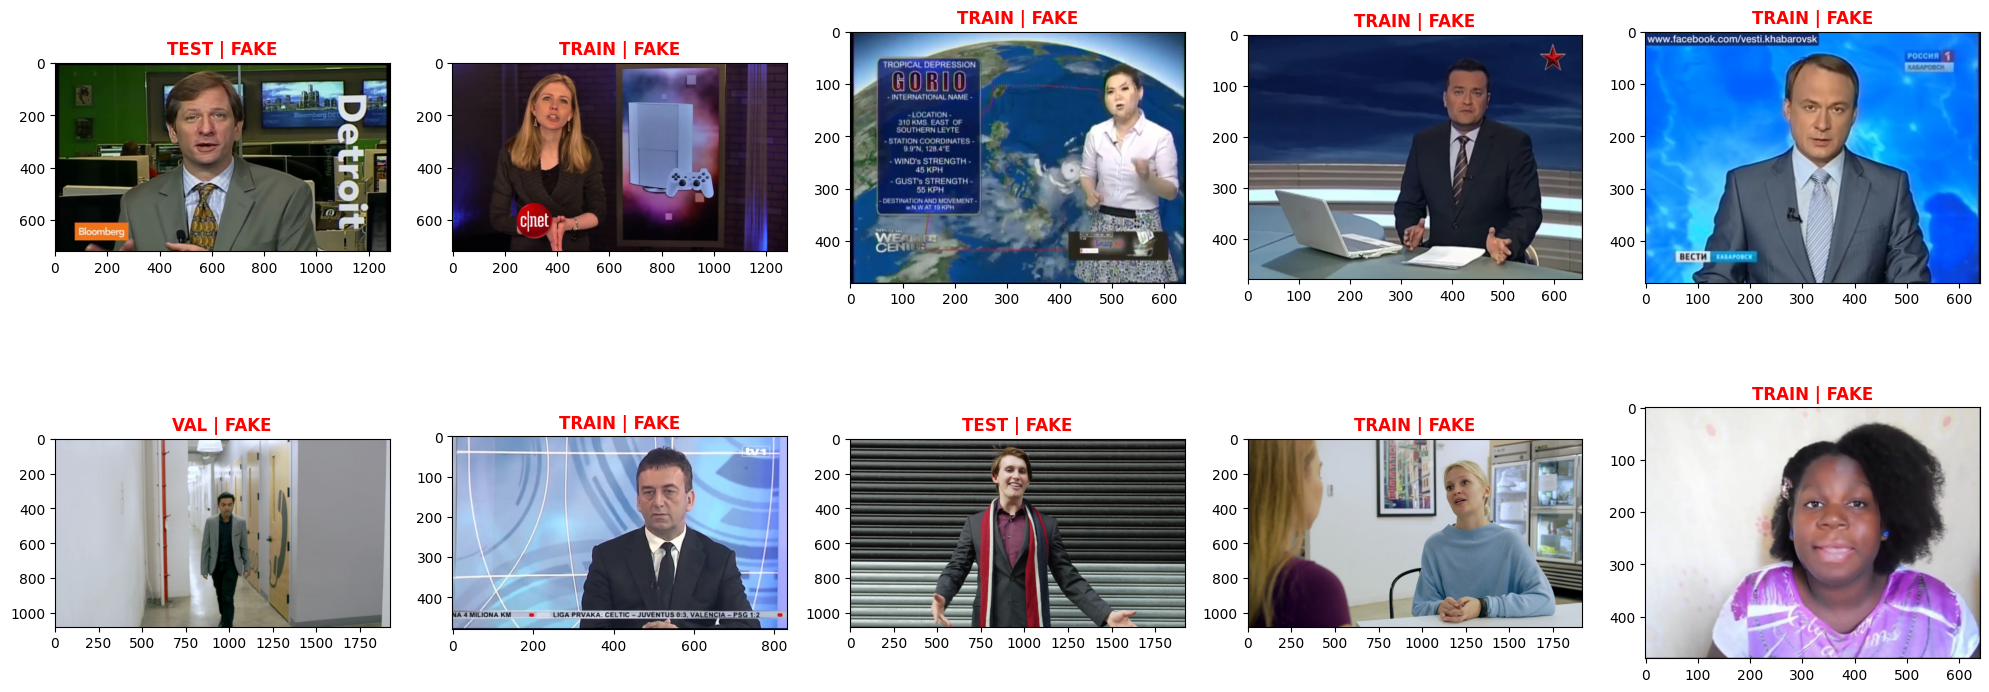

In [83]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_random_frames(base_path = "dataset_frames", num_images=10):
    all_frames = []

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(".jpg"):
                full_path = os.path.join(root,file)
                parts = root.split(os.sep)
                split = parts[-2]
                label = "REAL" if parts[-1] == "0" else "FAKE"
                all_frames.append((full_path, split, label))
    
    if not all_frames:
        print("No images founded")
        return 
    
    sample = random.sample(all_frames, min(num_images, len(all_frames)))

    cols = 5
    rows = (len(sample) + cols - 1) // cols
    plt.figure(figsize=(20, 4 * rows))

    for i, (img_path, split, label) in enumerate(sample):
        plt.subplot(rows, cols, i+1)
        img = Image.open(img_path)
        plt.imshow(img)

        title_color = 'green' if label == "REAL" else 'red'
        plt.title(f"{split.upper()} | {label}", color=title_color, fontweight='bold')

    plt.tight_layout()
    plt.show()

show_random_frames()